<h2>Predviđanje nivoa zavisnosti od mobilnih telefona kod tinejdžera - 2. Modeli</h2>
<h3>Uvod</h3>

U drugom delu rada, bavićemo se treniranjem i evauluacijom performansi različitih modela poput: Linearne regresije, XGBoost, KNN, i MLP NN. 

<h3>Pretprocesiranje</h3>

Za početak nedostajuće vrednosti i duplikati nisu pronadjeni. Atribut School_Grade čije su vrednosti bile redni brojevi na engleskom, su prebačeni u brojeve ('Seventh' -> 7). Kolona Location je izbačena jer nema nikakav uticaj na posmatranje problema zavisnosti. Za atribute Phone_Usage_Purpose i Gender je iskorišćen One hot encoding kako bi se pretvorile kategoričke vrednosti.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

import preprocessing

df = pd.read_csv("data/podaci.csv")
print(f"Dimenzija tabele: {df.shape}\n")

df_processed = preprocessing.preprocess(df)

print(f"\nNova dimenzija tabele: {df_processed.shape}")
print("\nPrvih 5 redova enkodiranih podataka:")
display(df_processed.head())

Dimenzija tabele: (3000, 25)

Nema nedostajućih vrednosti.

Nema duplikata.

Nova dimenzija tabele: (3000, 28)

Prvih 5 redova enkodiranih podataka:


,ID,Name,Age,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level,Gender_Male,Gender_Other,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,1,Shannon Francis,13,9,4.0,6.1,78,5,0.1,10,...,1.2,4,8.7,10.0,False,False,False,False,False,False
1,2,Scott Rodriguez,17,7,5.5,6.5,70,5,0.0,3,...,1.8,2,5.3,10.0,False,False,False,False,False,False
2,3,Adrian Knox,13,11,5.8,5.5,93,8,0.8,2,...,0.4,6,5.7,9.2,False,True,True,False,False,False
3,4,Brittany Hamilton,18,12,3.1,3.9,78,8,1.6,9,...,0.8,8,3.0,9.8,False,False,False,False,False,True
4,5,Steven Smith,14,9,2.5,6.7,56,4,1.1,1,...,1.1,10,3.7,8.6,False,True,False,True,False,False


<h3> Treniranje Linearne Regresije i XGBoost-a</h3>

Delimo podatke na trening i test skup u odnosu 70:30. 

Zbog malog broja podataka koristi se K-Fold cross-validation, dok se težinska regresija primenjuje da se ublaži asimetričnost ciljnog obeležja. 

K-fold (5 fold) split deli podatke na 5 delova, od kojih će 4 biti za trening i jedan za validaciju treniranih modela. Za svaki od trening foldova se trenira odvojen model i čuvaju rezultati dobijeni korišćenjem validacionog skupa. 

Metoda omogućava i dodavanje težina pri treniranju. Testiranjem različitih metoda dodavanja težina, odabrana je Log-smoothed inverse frequency, jer najbolje očuvava performanse modela, a efikasno ublažava asimteriju u raspodeli podataka.

$$
w_i = \log\left(1 + \frac{N}{c_{y_i}} \right)
$$

gde je:

- $N$ - ukupan broj uzoraka u trening skupu  
- $c_{y_i}$ - broj pojavljivanja klase kojoj pripada uzorak $i$  
- $w_i$ - težina dodeljena uzorku $i$

Konačni rezultat predstavljaju proseci po foldovima za metrike MAE, RMSE i R2. 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import models

X = df_processed.drop(columns=['Addiction_Level', 'ID', 'Name'], errors='ignore')
y = df_processed['Addiction_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treniranje sa K-Fold validacijom
models.train_model_with_cv(LinearRegression(), X_train, y_train, use_weights=False)
models.train_model_with_cv(LinearRegression(), X_train, y_train, use_weights=True)

models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=False)
models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=True)


===== LinearRegression (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.6765
CV Prosečan RMSE (Trening): 0.8428
CV Prosečan R2 Score (Trening): 0.7303

===== LinearRegression (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.7154
CV Prosečan RMSE (Trening): 0.9126
CV Prosečan R2 Score (Trening): 0.6821

===== XGBRegressor (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.3629
CV Prosečan RMSE (Trening): 0.5331
CV Prosečan R2 Score (Trening): 0.8918

===== XGBRegressor (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.3832
CV Prosečan RMSE (Trening): 0.5533
CV Prosečan R2 Score (Trening): 0.8834


Možemo uočiti da XGBoost daje znatno bolje rezultate od Linearne regresije, i zbog toga ćemo taj model koristiti za finalnu evaluaciju. Takođe možemo primetiti mali pad u performansama pri korišćenju težina, što je i očekivano. Model sa težinama će bolje prediktovati manje prisutne nivoe zavisnosti, po cenu malog pada u performansama.

In [3]:
# Rezultati na test skupu
results_standard = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=False)
results_weighted = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=True)


===== XGBRegressor (Finalni Standard) =====
Finalni MAE (Test): 0.3500
Finalni RMSE (Test): 0.5103
Finalni R2 Score (Test): 0.8943

===== XGBRegressor (Finalni Weighted) =====
Finalni MAE (Test): 0.3515
Finalni RMSE (Test): 0.5006
Finalni R2 Score (Test): 0.8983


Nad dobijenim rezultatima vršimo analizu tako što delimo podatke na 3 dela. Cilj je ispitati efikasnost dodavanja težina.

Broj uzoraka po segmentima:
1-7: 125
7-9: 201
9-10: 574

Rezultati po segmentima:
1-7: MAE = 0.6669, RMSE = 0.8477
7-9: MAE = 0.4672, RMSE = 0.5800
9-10: MAE = 0.2400, RMSE = 0.3661


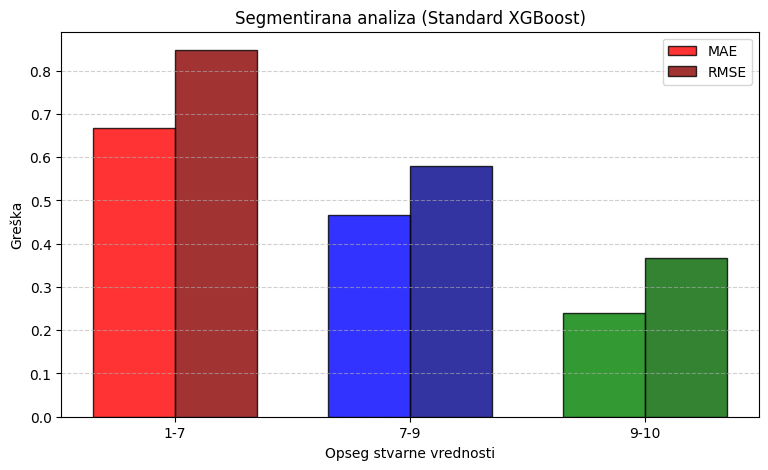

In [4]:
# Standardni XGBoost
models.plot_segmented_analysis(results_standard, title="Segmentirana analiza (Standard XGBoost)")

Na grafikonu iznad možemo uočiti znatan porast grešaka, pri nižim vrednostima zavisnosti.

Broj uzoraka po segmentima:
1-7: 125
7-9: 201
9-10: 574

Rezultati po segmentima:
1-7: MAE = 0.6540, RMSE = 0.8151
7-9: MAE = 0.4282, RMSE = 0.5463
9-10: MAE = 0.2587, RMSE = 0.3791


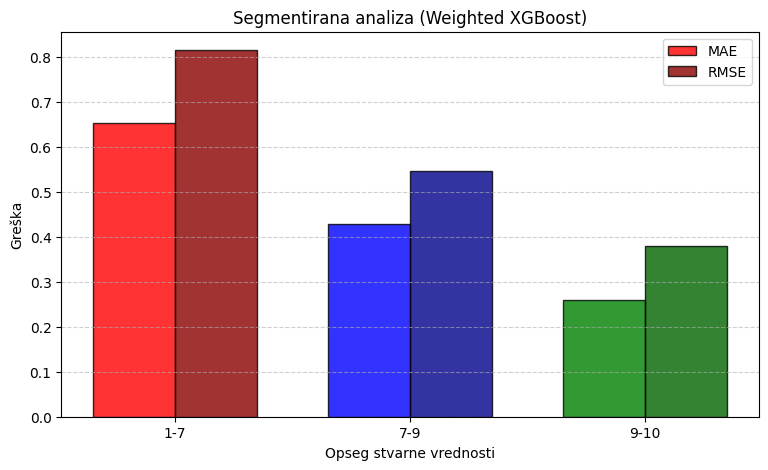

In [5]:
# Weighted XGBoost
models.plot_segmented_analysis(results_weighted, title="Segmentirana analiza (Weighted XGBoost)")

Broj uzoraka i MAE po segmentima:
1-7: n=125, Standard XGBoost MAE=0.6669, Weighted XGBoost MAE=0.6540
7-9: n=201, Standard XGBoost MAE=0.4672, Weighted XGBoost MAE=0.4282
9-10: n=574, Standard XGBoost MAE=0.2400, Weighted XGBoost MAE=0.2587


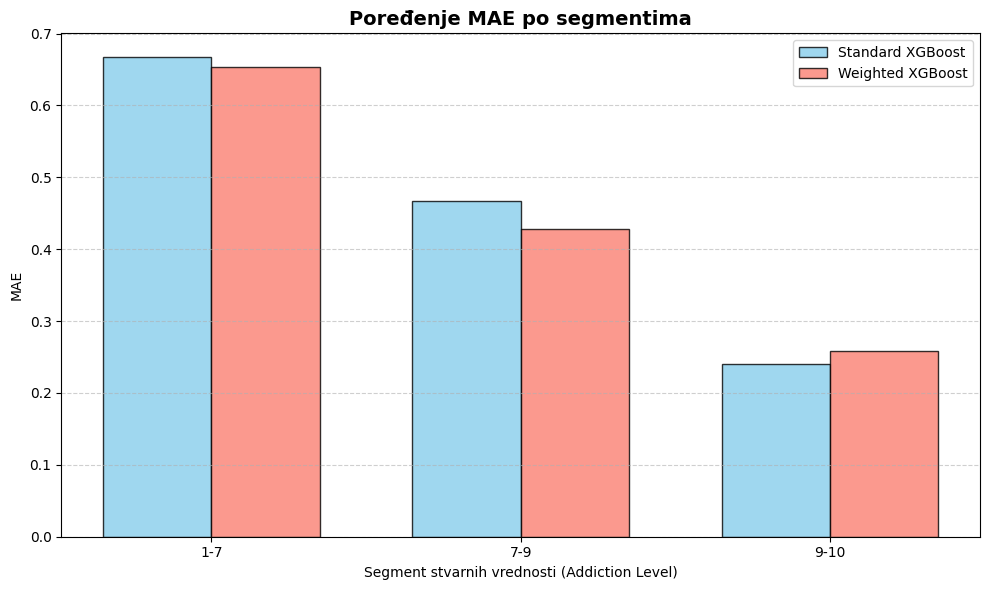

In [6]:
models.compare_segmented_mae(results_standard, results_weighted, labels=("Standard XGBoost", "Weighted XGBoost"))

Na osnovu grafikona i priloženih rezultata, možemo konstatovati da je primena težinskog faktora bila uspešna. Glavni cilj balansiranja je da model više vrednuje ređe podatke. 

Segment 1-7 beleži mali napredak, gde je MAE pao sa 0.67 na 0.65. Uspeh je ipak ograničen malim pojavljivanjem ovih vrednosti.

Segment 7-9 beleži značajniji uspeh, gde je MAE smanjem sa 0.467 na 0.428, što pokazuje da je model postao osetljiviji na ove vrednosti.

Segment 9-10 predstavlja cenu ovog balansiranja, gde je MAE blago porastao sa 0.24 na 0.258, što je prihvatljivo.

Konačno možemo zaključiti da se Log-smoothed inverse frequency dobro pokazao, jer minimalno pogoršava generalni rezultat, ali povećava pouzdanost predikcija u nižem i srednjem segmentu.